# Generalized Extreme Value Distribution

What is the distribution of the **maximum** of a large collection of independent random variables? This question — central to risk analysis, climate science, hydrology, and finance — is answered by the **Fisher–Tippett–Gnedenko theorem** (1928–1943), one of the fundamental limit theorems of probability:

> Under mild conditions, the properly normalized maximum $M_n = \max(X_1,\ldots,X_n)$ converges in distribution to a member of the **Generalized Extreme Value (GEV) family**.

## The GEV family

The GEV distribution is parameterized by a single **shape parameter** $\xi \in \mathbb{R}$ (plus location $\mu$ and scale $\sigma$, which we set to $0$ and $1$ here). Its CDF is:
$$
F(x;\xi) = \begin{cases}
\exp\!\bigl(-(1+\xi x)^{-1/\xi}\bigr) & \xi \neq 0, \quad 1+\xi x > 0, \\
\exp(-e^{-x}) & \xi = 0.
\end{cases}
$$
Differentiating gives the PDF:
$$
f(x;\xi) = F(x;\xi) \cdot \begin{cases}
(1+\xi x)^{-1-1/\xi} & \xi \neq 0, \\
e^{-x} & \xi = 0.
\end{cases}
$$

## Three sub-families

The shape $\xi$ controls the tail behavior:

| $\xi$ | Name | Support | Tail | Domain of attraction |
|---|---|---|---|---|
| $\xi = 0$ | **Gumbel** (Type I) | $(-\infty,+\infty)$ | Exponential | Normal, Exponential, Gamma |
| $\xi > 0$ | **Fréchet** (Type II) | $(−1/\xi, +\infty)$ | Power law (heavy) | Pareto, Cauchy, Student-$t$ |
| $\xi < 0$ | **Weibull** (Type III) | $(-\infty, -1/\xi)$ | Finite upper endpoint | Uniform, Beta |

The GEV unifies all three cases and allows continuous interpolation between them. In practice, $\xi$ is estimated from observed maxima (e.g. annual flood peaks, daily maximum temperatures) to identify which tail regime governs the data — critical for estimating the probability of rare events like 100-year floods.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from ipywidgets import interact, FloatSlider

plt.rcParams["figure.dpi"] = 120

## GEV CDF and PDF

We implement the GEV CDF and PDF directly from the formulas above. Special care is needed for $\xi \approx 0$ (Gumbel limit) and for the support constraint $1 + \xi x > 0$.

In [2]:
def gev_cdf(x, xi):
    """GEV CDF with shape xi (location 0, scale 1)."""
    x = np.asarray(x, dtype=float)
    if abs(xi) < 1e-10:  # Gumbel
        return np.exp(-np.exp(-x))
    t = 1 + xi * x
    result = np.where(t > 0, np.exp(-np.maximum(t, 1e-300) ** (-1.0 / xi)), 0.0)
    if xi > 0:
        result = np.where(t <= 0, 0.0, result)
    else:
        result = np.where(t <= 0, 1.0, result)
    return result


def gev_pdf(x, xi):
    """GEV PDF with shape xi (location 0, scale 1)."""
    x = np.asarray(x, dtype=float)
    F = gev_cdf(x, xi)
    if abs(xi) < 1e-10:  # Gumbel
        return F * np.exp(-x)
    t = 1 + xi * x
    result = np.where(t > 0,
                      F * np.maximum(t, 1e-300) ** (-1.0 - 1.0 / xi),
                      0.0)
    return np.maximum(result, 0.0)


print("GEV functions ready.")

GEV functions ready.


## The three GEV sub-families

We plot the PDFs for representative values of $\xi$ in each of the three regimes: Weibull ($\xi < 0$), Gumbel ($\xi = 0$), and Fréchet ($\xi > 0$). Notice how:
- **Weibull** densities have a hard upper boundary at $x = -1/\xi$;
- **Gumbel** has an exponential right tail;
- **Fréchet** densities have heavy power-law right tails that decay much more slowly.

/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_64360/3494324259.py:7: RuntimeWarning: overflow encountered in power
  result = np.where(t > 0, np.exp(-np.maximum(t, 1e-300) ** (-1.0 / xi)), 0.0)
/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_64360/3494324259.py:23: RuntimeWarning: overflow encountered in power
  F * np.maximum(t, 1e-300) ** (-1.0 - 1.0 / xi),
/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_64360/3494324259.py:23: RuntimeWarning: invalid value encountered in multiply
  F * np.maximum(t, 1e-300) ** (-1.0 - 1.0 / xi),


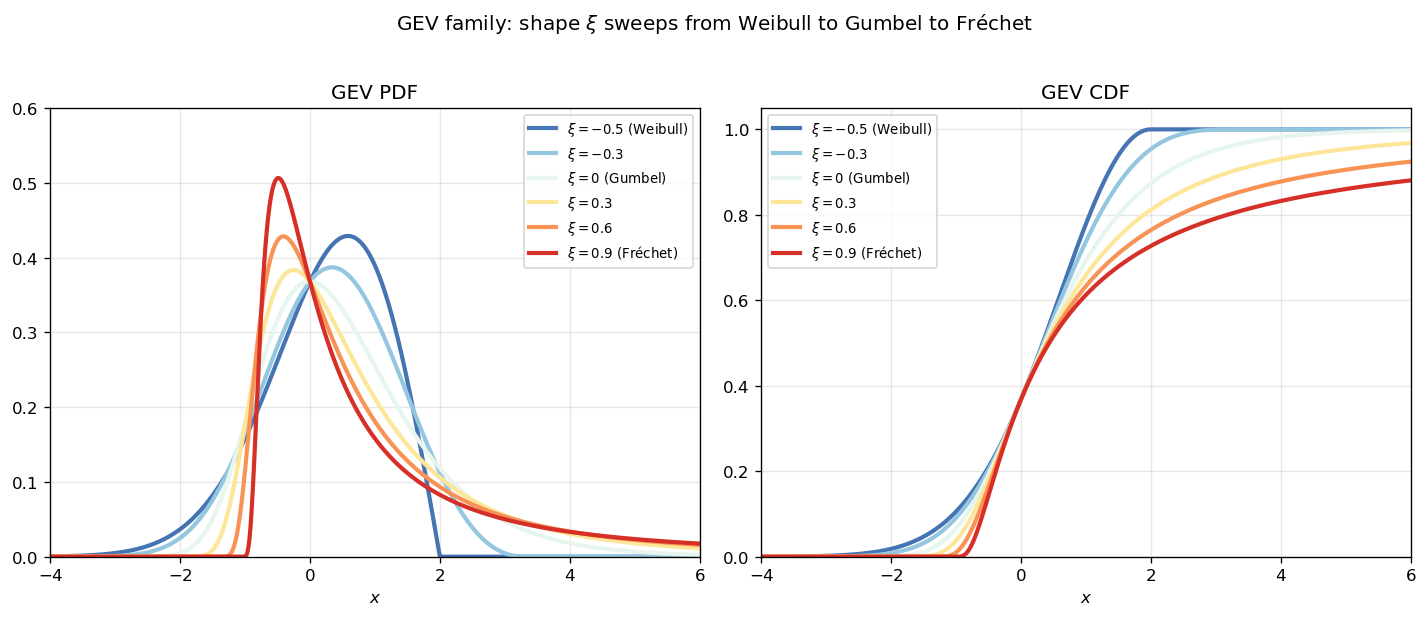

In [3]:
x = np.linspace(-4, 6, 2000)

xi_vals = [-0.5, -0.3, 0.0, 0.3, 0.6, 0.9]
labels  = [r"$\xi=-0.5$ (Weibull)", r"$\xi=-0.3$",
           r"$\xi=0$ (Gumbel)",
           r"$\xi=0.3$", r"$\xi=0.6$", r"$\xi=0.9$ (Fréchet)"]
colors  = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(xi_vals)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for xi, lbl, col in zip(xi_vals, labels, colors):
    axes[0].plot(x, gev_pdf(x, xi), lw=2.5, color=col, label=lbl)
    axes[1].plot(x, gev_cdf(x, xi), lw=2.5, color=col, label=lbl)

axes[0].set_xlim(-4, 6); axes[0].set_ylim(0, 0.60)
axes[0].set_title("GEV PDF"); axes[0].set_xlabel("$x$")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_xlim(-4, 6); axes[1].set_ylim(0, 1.05)
axes[1].set_title("GEV CDF"); axes[1].set_xlabel("$x$")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

fig.suptitle("GEV family: shape $\\xi$ sweeps from Weibull to Gumbel to Fréchet", y=1.02)
plt.tight_layout()
plt.show()

## Empirical verification: block maxima

The **block maxima method** fits GEV to data by dividing a long record into blocks and taking the maximum of each. Here we verify the theorem empirically: for $n$ i.i.d. $\mathrm{Exponential}(1)$ variables, the normalized maximum $M_n - \ln n$ converges to the Gumbel distribution ($\xi = 0$). For $\mathrm{Pareto}(\alpha)$ variables, the limit is Fréchet with $\xi = 1/\alpha$.

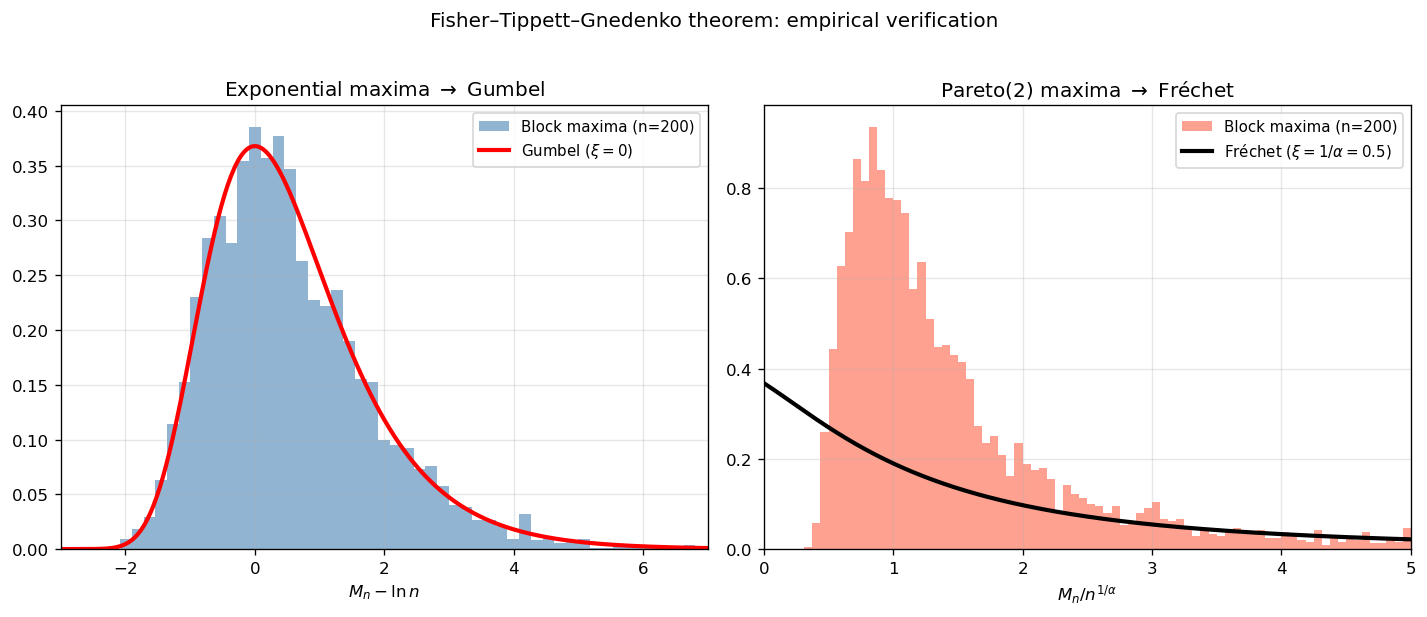

In [4]:
rng = np.random.default_rng(42)
n_block = 200    # block size
n_blocks = 4000  # number of blocks

# Exponential -> Gumbel
exp_data = rng.exponential(1.0, size=(n_blocks, n_block))
exp_maxima = exp_data.max(axis=1) - np.log(n_block)  # normalize

# Pareto(2) -> Fréchet(xi=0.5)
alpha = 2.0
par_data = (rng.pareto(alpha, size=(n_blocks, n_block)) + 1)
# normalize: M_n / n^(1/alpha)
par_maxima = par_data.max(axis=1) / n_block ** (1.0 / alpha)

x_gum = np.linspace(-3, 7, 400)
x_fre = np.linspace(0.01, 5, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(exp_maxima, bins=60, density=True, alpha=0.6, color="steelblue",
             label=f"Block maxima (n={n_block})")
axes[0].plot(x_gum, gev_pdf(x_gum, 0.0), 'r-', lw=2.5, label="Gumbel ($\\xi=0$)")
axes[0].set_title("Exponential maxima $\\to$ Gumbel")
axes[0].set_xlabel(r"$M_n - \ln n$"); axes[0].legend(fontsize=9)
axes[0].set_xlim(-3, 7); axes[0].grid(alpha=0.3)

xi_fre = 1.0 / alpha
axes[1].hist(par_maxima, bins=80, density=True, alpha=0.6, color="tomato",
             label=f"Block maxima (n={n_block})", range=(0, 5))
axes[1].plot(x_fre, gev_pdf(x_fre, xi_fre), 'k-', lw=2.5,
             label=fr"Fréchet ($\xi=1/\alpha={xi_fre}$)")
axes[1].set_title("Pareto(2) maxima $\\to$ Fréchet")
axes[1].set_xlabel(r"$M_n / n^{1/\alpha}$"); axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 5); axes[1].grid(alpha=0.3)

fig.suptitle("Fisher–Tippett–Gnedenko theorem: empirical verification", y=1.02)
plt.tight_layout()
plt.show()

## Bibliographical resources

- Fisher, R. A. and Tippett, L. H. C. (1928). Limiting forms of the frequency distribution of the largest or smallest member of a sample. *Proceedings of the Cambridge Philosophical Society*, 24(2), 180–190.
- Gnedenko, B. (1943). Sur la distribution limite du terme maximum d'une série aléatoire. *Annals of Mathematics*, 44(3), 423–453.
- Gumbel, E. J. (1958). *Statistics of Extremes*. Columbia University Press.
- Coles, S. (2001). *An Introduction to Statistical Modeling of Extreme Values*. Springer.
- de Haan, L. and Ferreira, A. (2006). *Extreme Value Theory: An Introduction*. Springer.

## Maxima-CLT style extension across three $\xi$ regimes


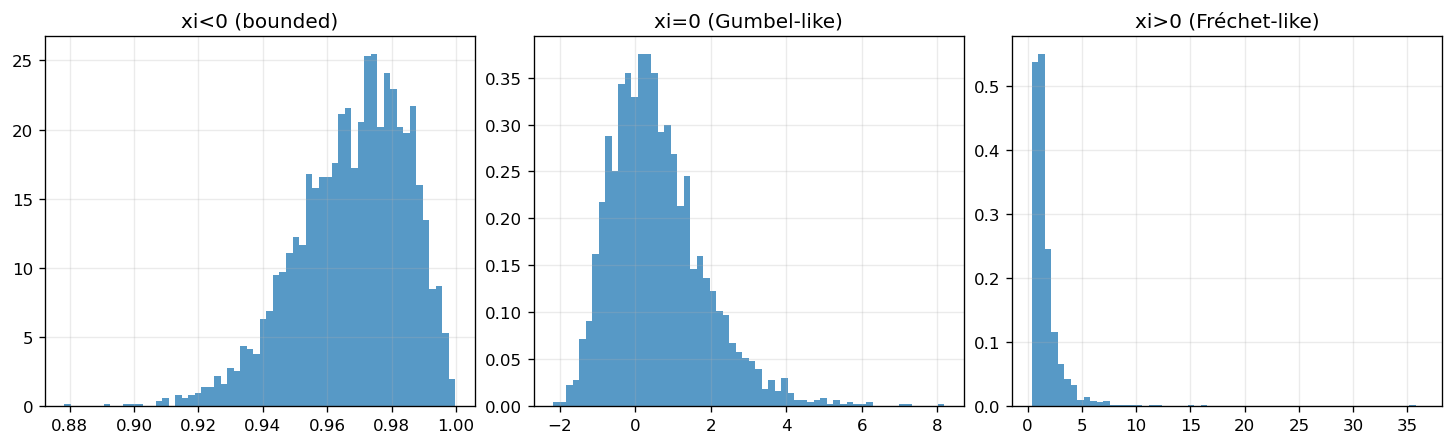

In [5]:
rng2 = np.random.default_rng(123)
n_block = 180
n_blocks = 2500
# xi<0 (bounded): Beta tail surrogate
wb = rng2.beta(2.5, 2.0, size=(n_blocks, n_block)).max(axis=1)
# xi=0: exponential
gb = rng2.exponential(1.0, size=(n_blocks, n_block)).max(axis=1) - np.log(n_block)
# xi>0: Pareto heavy tail
pb = (rng2.pareto(2.0, size=(n_blocks, n_block)) + 1).max(axis=1) / n_block**0.5
fig, axes = plt.subplots(1,3, figsize=(12,3.6), constrained_layout=True)
for ax, z, ttl in zip(axes, [wb, gb, pb], ['xi<0 (bounded)', 'xi=0 (Gumbel-like)', 'xi>0 (Fréchet-like)']):
    ax.hist(z, bins=60, density=True, alpha=0.75)
    ax.set_title(ttl)
    ax.grid(alpha=0.25)
plt.show()
